In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore minor warnings
warnings.filterwarnings('ignore')

# Load the dataset from the CSV file
try:
    df = pd.read_csv('final_model_data.csv')
except FileNotFoundError:
    print("Error: 'dataset.csv' not found.")
    print("Please make sure the data is saved in a file named 'dataset.csv' in the correct directory.")

    import io
    df = pd.read_csv(io.StringIO(csv_data))

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Display basic information
print("## Data Info")
df.info()

# Display summary statistics
print("\n## Summary Statistics")
print(df.describe())

# Check for missing values
print("\n## Missing Values")
print(df.isnull().sum())

## Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         93 non-null     datetime64[ns]
 1   river_water_area_sqkm        93 non-null     float64       
 2   mean_elevation_meters        93 non-null     float64       
 3   mean_slope_degrees           93 non-null     float64       
 4   land_cover_class_10_percent  93 non-null     float64       
 5   land_cover_class_20_percent  93 non-null     float64       
 6   land_cover_class_30_percent  93 non-null     float64       
 7   land_cover_class_40_percent  93 non-null     float64       
 8   land_cover_class_50_percent  93 non-null     float64       
 9   land_cover_class_60_percent  93 non-null     float64       
 10  land_cover_class_80_percent  93 non-null     float64       
 11  rainfall_mm                  93 no

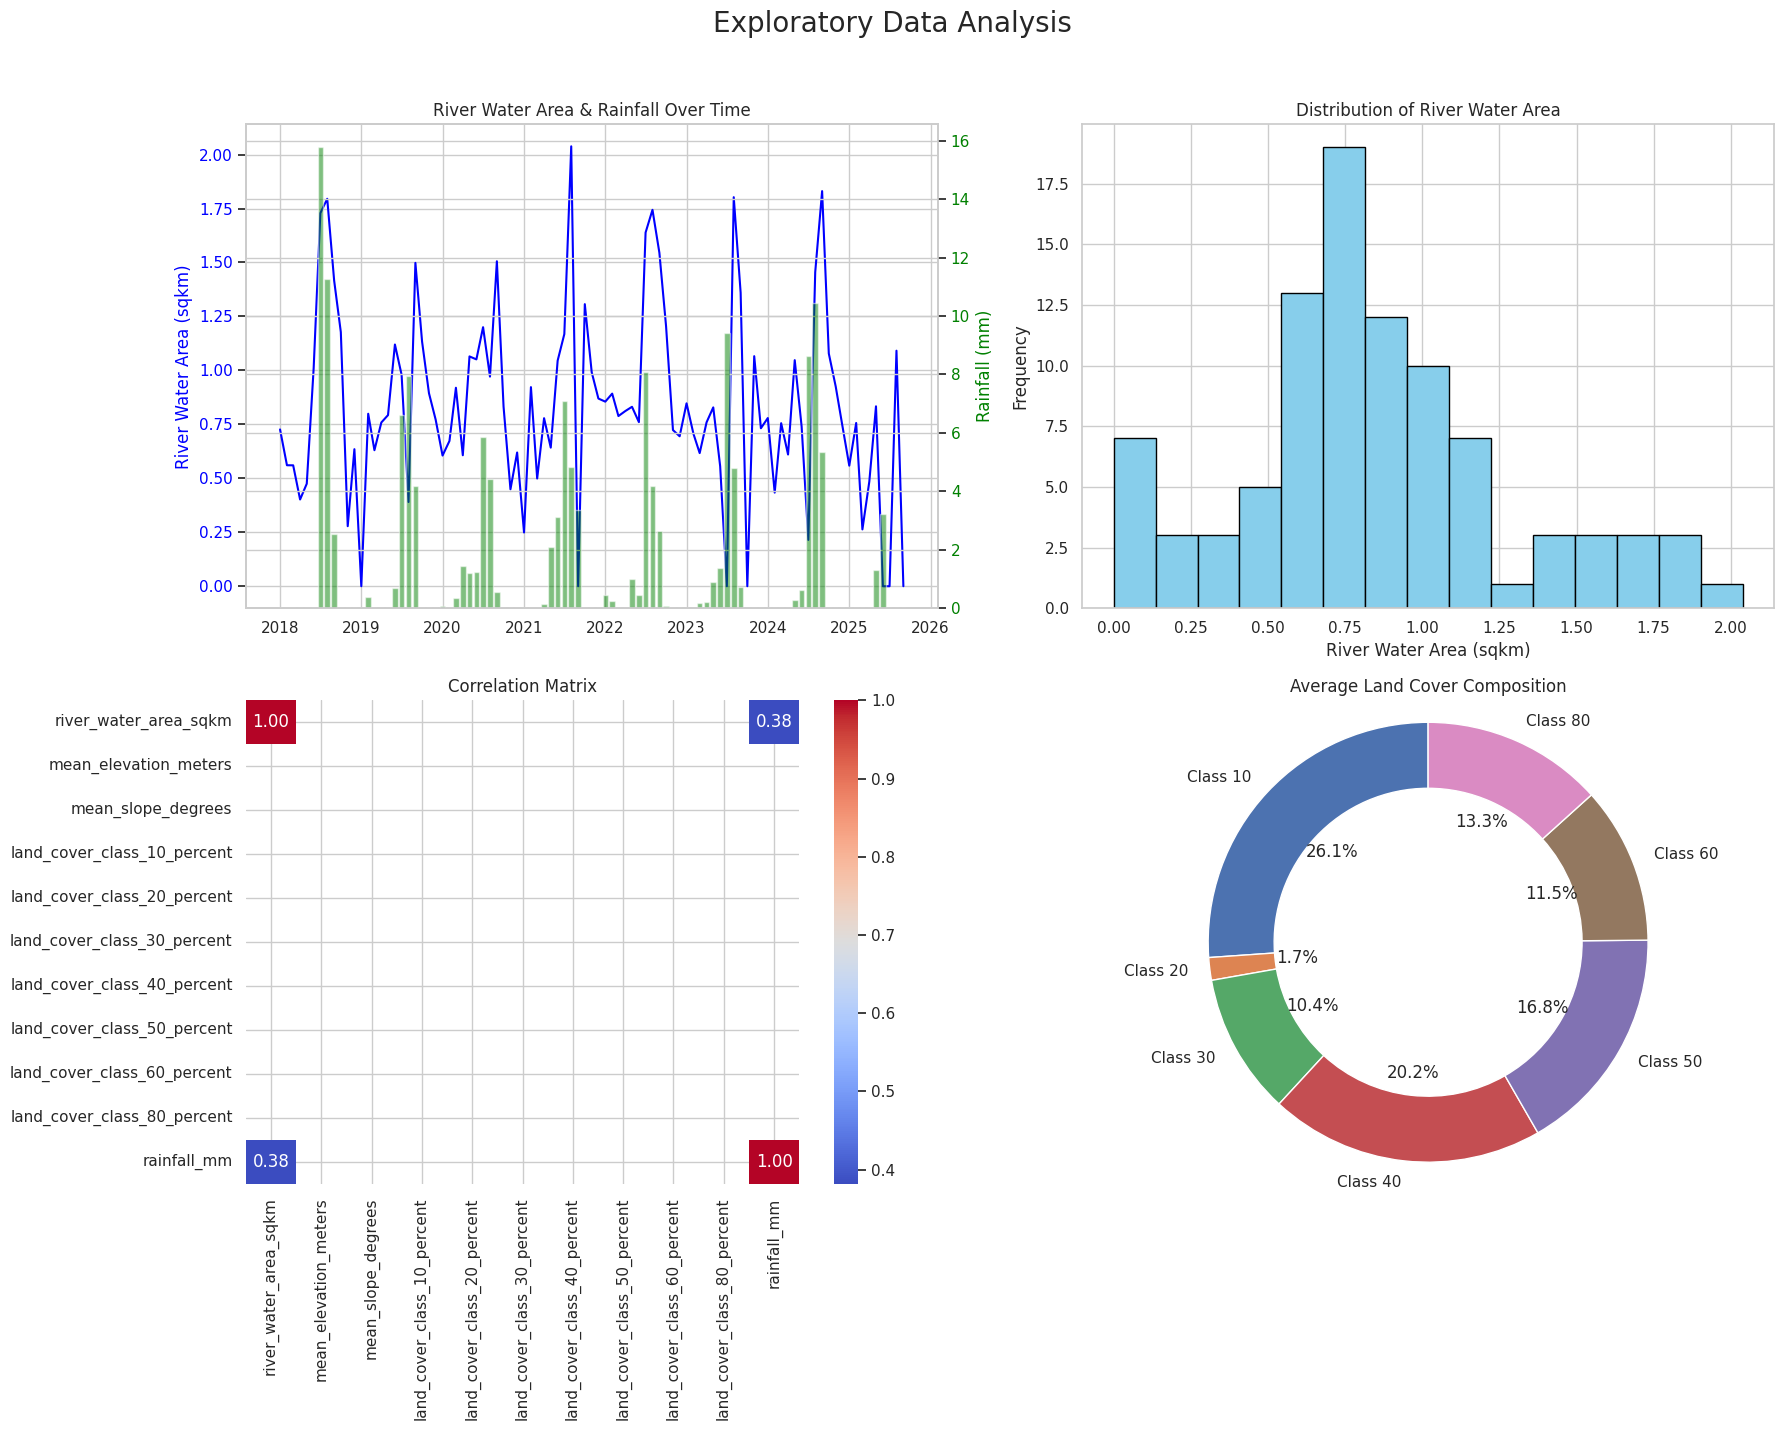

In [ ]:
# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure to hold all subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Exploratory Data Analysis', fontsize=20, y=1.02)

# 1. Time Series of River Water Area and Rainfall
ax1 = axes[0, 0]
ax1.plot(df['date'], df['river_water_area_sqkm'], color='blue', label='River Water Area (sqkm)')
ax1.set_ylabel('River Water Area (sqkm)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('River Water Area & Rainfall Over Time')
ax1.grid(True)

ax2 = ax1.twinx()  # Create a second y-axis
ax2.bar(df['date'], df['rainfall_mm'], color='green', alpha=0.5, width=25, label='Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# 2. Distribution of Key Variables
axes[0, 1].hist(df['river_water_area_sqkm'], bins=15, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Distribution of River Water Area')
axes[0, 1].set_xlabel('River Water Area (sqkm)')
axes[0, 1].set_ylabel('Frequency')

# 3. Correlation Matrix Heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Land Cover Composition Pie Chart
land_cover_cols = [col for col in df.columns if 'land_cover_class' in col]
land_cover_means = df[land_cover_cols].mean()
labels = [f'Class {col.split("_")[3]}' for col in land_cover_cols]
axes[1, 1].pie(land_cover_means, labels=labels, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
axes[1, 1].set_title('Average Land Cover Composition')
axes[1, 1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.


# Adjust layout and display the plots
plt.tight_layout()
plt.show()

📊 ## 1. Descriptive & Summary Analysis ##

### Data Head:
            river_water_area_sqkm  mean_elevation_meters  mean_slope_degrees  \
date                                                                           
2018-01-01               0.726325             291.700789            5.154286   
2018-02-01               0.560461             291.700789            5.154286   
2018-03-01               0.560115             291.700789            5.154286   
2018-04-01               0.401864             291.700789            5.154286   
2018-05-01               0.474928             291.700789            5.154286   

            land_cover_class_10_percent  land_cover_class_20_percent  \
date                                                                   
2018-01-01                    26.111203                     1.665582   
2018-02-01                    26.111203                     1.665582   
2018-03-01                    26.111203                     1.665582   
2018-04-01           

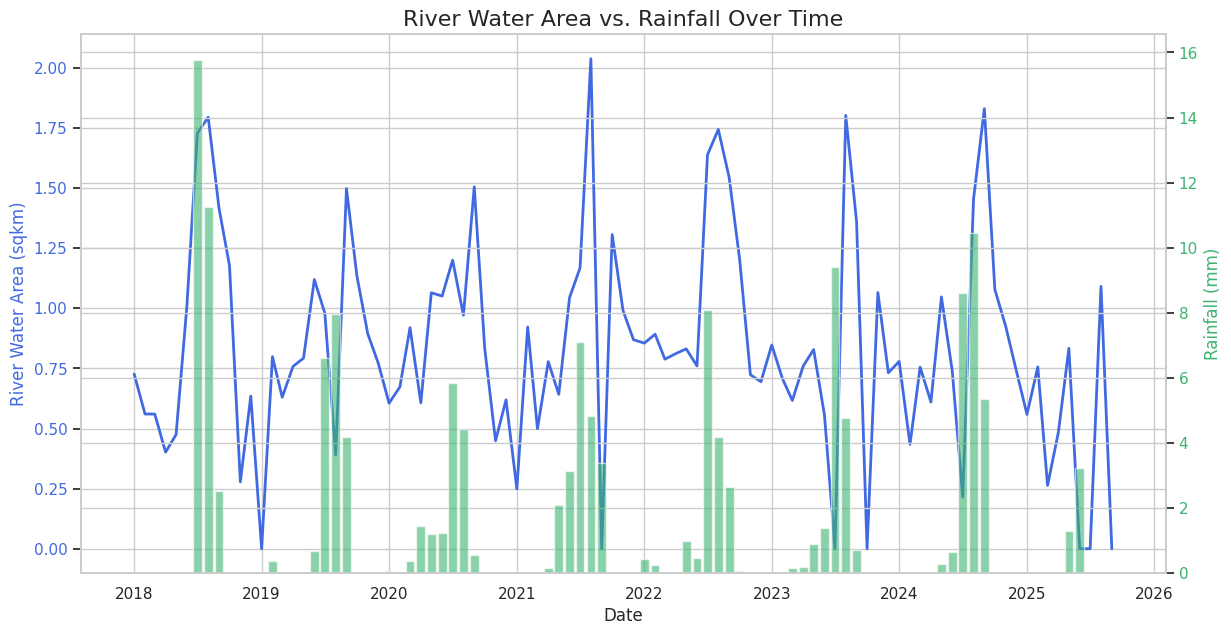

Generating: Seasonal Box Plot


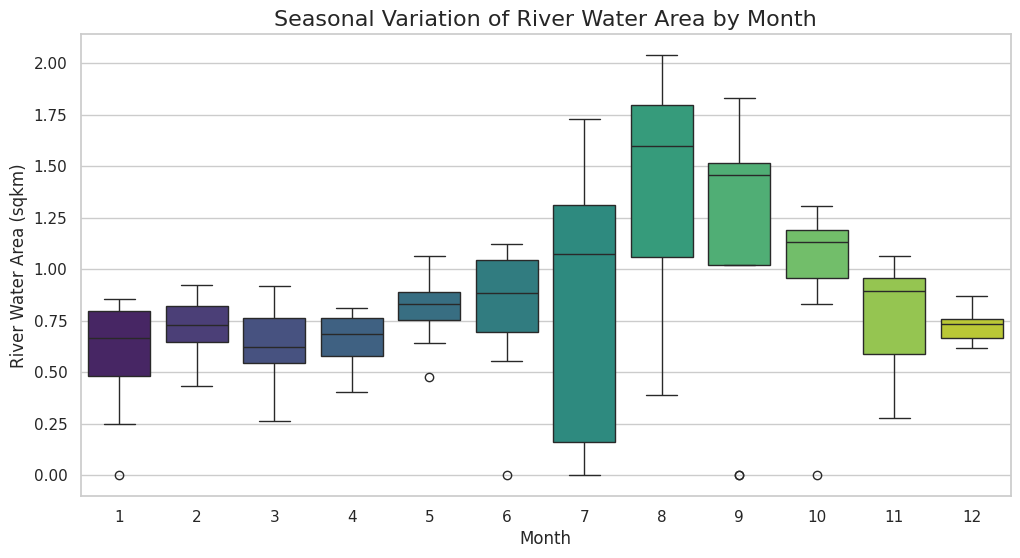

Generating: Time Series Decomposition Plot


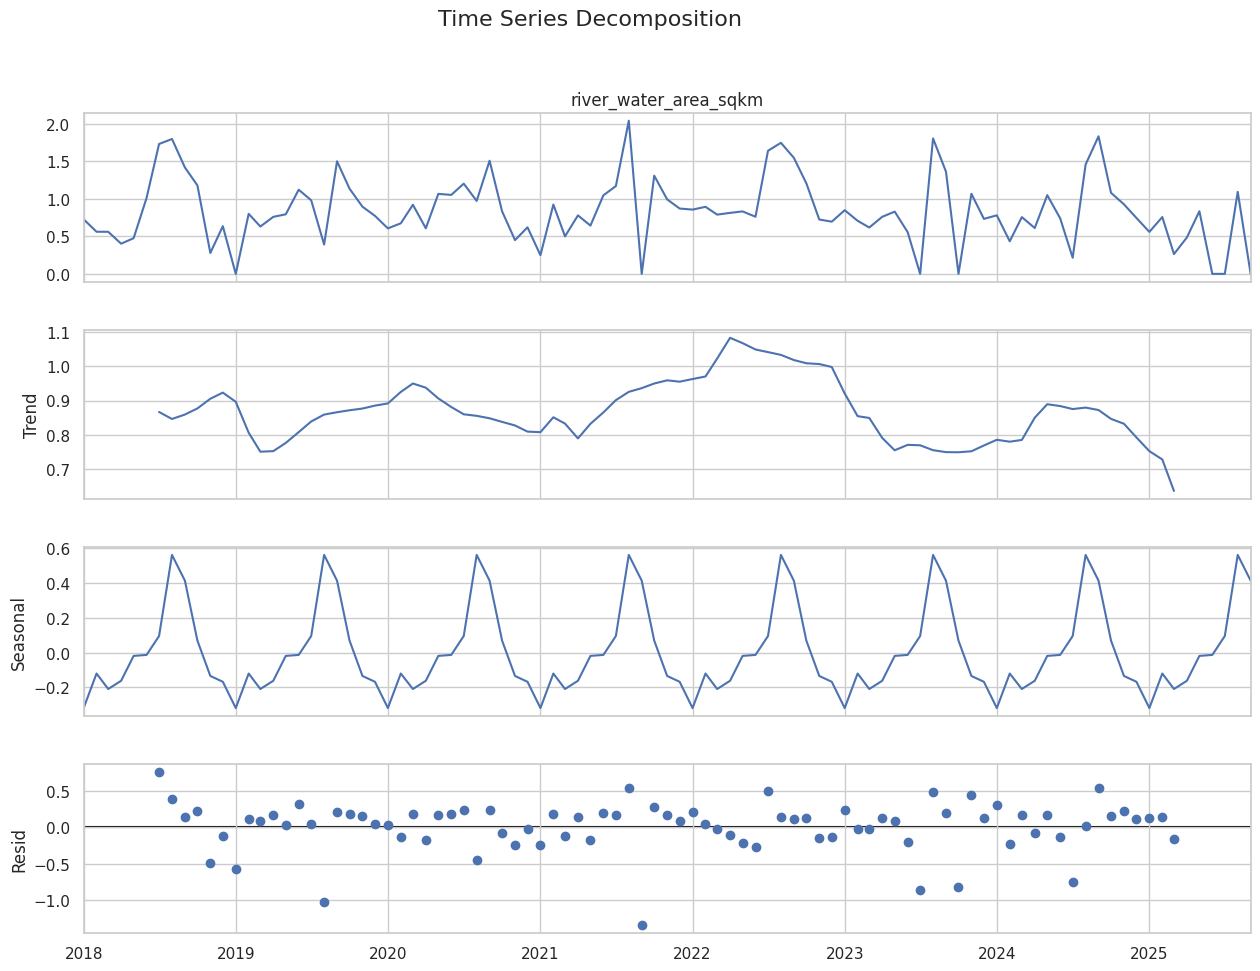

--------------------------------------------------
Generating: Scatter Plot


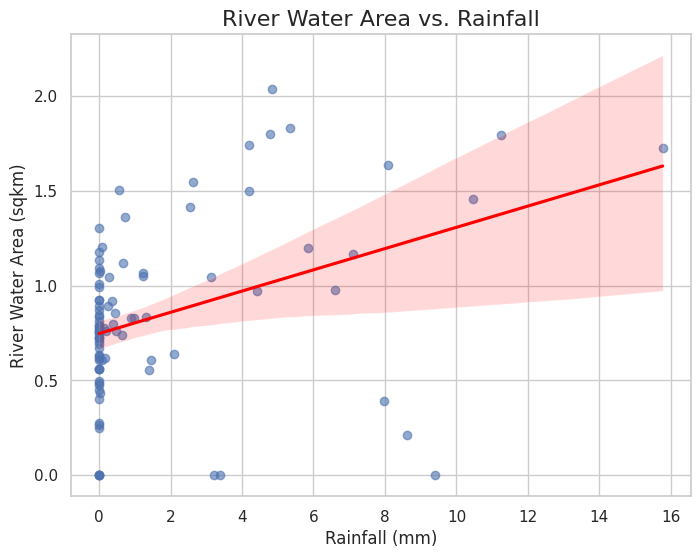

--------------------------------------------------

🗺️ ## 3. Feature-Specific Analysis ##
Generating: Distribution Histograms


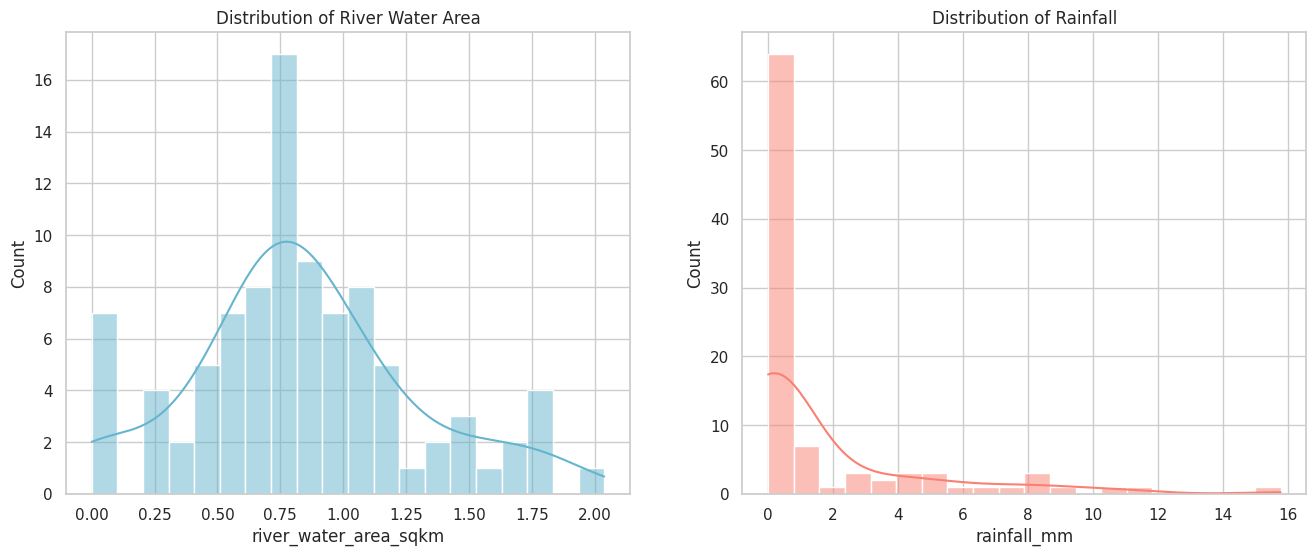


🤖 ## 4. Preparation for Predictive Modeling ##
Demonstrating Feature Engineering from the date index.

### DataFrame with New Features:
            year  month  quarter  day_of_year  rainfall_mm  rainfall_lag_1
date                                                                      
2018-01-01  2018      1        1            1          0.0             NaN
2018-02-01  2018      2        1           32          0.0             0.0
2018-03-01  2018      3        1           60          0.0             0.0
2018-04-01  2018      4        2           91          0.0             0.0
2018-05-01  2018      5        2          121          0.0             0.0
--------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

# --- 0. Setup ---
# Ignore minor warnings for a cleaner output
warnings.filterwarnings('ignore')
# Set a consistent style for all plots
sns.set_theme(style="whitegrid")


# --- 1. Load Data ---
try:
    # Try to load the dataset from a local CSV file
    df = pd.read_csv('final_model_data.csv')
except FileNotFoundError:
    print("--- 'dataset.csv' not found. ---")
    print("Loading data from the provided text string as a fallback.\n")
    # If the file isn't found, use the string data provided earlier
    import io

# Convert 'date' column to datetime objects and set it as the index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


# --- 2. Descriptive & Summary Analysis ---
print("📊 ## 1. Descriptive & Summary Analysis ##")
print("\n### Data Head:")
print(df.head())
print("\n### Data Information:")
df.info()
print("\n### Summary Statistics:")
print(df.describe())
print("\n### Missing Values Check:")
print(df.isnull().sum())
print("-" * 50)


# --- 3. Time Series & Trend Analysis ---
print("\n📈 ## 2. Time Series & Trend Analysis ##")
# a) Dual-Axis Time Series Plot
print("Generating: Dual-Axis Time Series Plot")
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(df.index, df['river_water_area_sqkm'], color='royalblue', label='River Water Area (sqkm)', linewidth=2)
ax1.set_ylabel('River Water Area (sqkm)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax2 = ax1.twinx()
ax2.bar(df.index, df['rainfall_mm'], color='mediumseagreen', alpha=0.6, width=25, label='Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='mediumseagreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='mediumseagreen')
ax1.set_title('River Water Area vs. Rainfall Over Time', fontsize=16)
ax1.set_xlabel('Date', fontsize=12)
plt.show()

# b) Seasonal Analysis with Box Plots
print("Generating: Seasonal Box Plot")
df['month'] = df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='river_water_area_sqkm', data=df, palette='viridis')
plt.title('Seasonal Variation of River Water Area by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('River Water Area (sqkm)', fontsize=12)
plt.show()

# c) Time Series Decomposition
print("Generating: Time Series Decomposition Plot")
# Use a period of 12 for monthly data with a yearly cycle
decomposition = seasonal_decompose(df['river_water_area_sqkm'], model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition', y=1.02, fontsize=16)
plt.show()
print("-" * 50)


# --- 4. Relationship & Correlation Analysis ---

# b) Scatter Plot
print("Generating: Scatter Plot")
plt.figure(figsize=(8, 6))
sns.regplot(x='rainfall_mm', y='river_water_area_sqkm', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('River Water Area vs. Rainfall', fontsize=16)
plt.xlabel('Rainfall (mm)', fontsize=12)
plt.ylabel('River Water Area (sqkm)', fontsize=12)
plt.show()
print("-" * 50)


# --- 5. Feature-Specific Analysis ---
print("\n🗺️ ## 3. Feature-Specific Analysis ##")
# a) Distribution Histograms
print("Generating: Distribution Histograms")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['river_water_area_sqkm'], bins=20, kde=True, ax=axes[0], color='c')
axes[0].set_title('Distribution of River Water Area')
sns.histplot(df['rainfall_mm'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Rainfall')
plt.show()


# --- 6. Preparation for Predictive Modeling ---
print("\n🤖 ## 4. Preparation for Predictive Modeling ##")
print("Demonstrating Feature Engineering from the date index.\n")
# Create time-based features
df['year'] = df.index.year
df['quarter'] = df.index.quarter
df['day_of_year'] = df.index.dayofyear

# Create lag features (e.g., rainfall from the previous month)
df['rainfall_lag_1'] = df['rainfall_mm'].shift(1)

print("### DataFrame with New Features:")
# Show the new features created
print(df[['year', 'month', 'quarter', 'day_of_year', 'rainfall_mm', 'rainfall_lag_1']].head())
print("-" * 50)

--- Successfully loaded 'final_rain_data.csv' ---

--- Descriptive Statistics ---
                             count        mean           std         min  \
river_water_area_sqkm         93.0    0.837687  4.481990e-01    0.000000   
mean_elevation_meters         93.0  291.700789  1.143030e-13  291.700789   
mean_slope_degrees            93.0    5.154286  8.036932e-15    5.154286   
land_cover_class_10_percent   93.0   26.111203  2.500379e-14   26.111203   
land_cover_class_20_percent   93.0    1.665582  1.339489e-15    1.665582   
land_cover_class_30_percent   93.0   10.373379  1.250189e-14   10.373379   
land_cover_class_40_percent   93.0   20.170035  1.071591e-14   20.170035   
land_cover_class_50_percent   93.0   16.832981  2.857576e-14   16.832981   
land_cover_class_60_percent   93.0   11.531081  8.929924e-15   11.531081   
land_cover_class_80_percent   93.0   13.315739  1.071591e-14   13.315739   

                                    25%         50%         75%         max  
riv

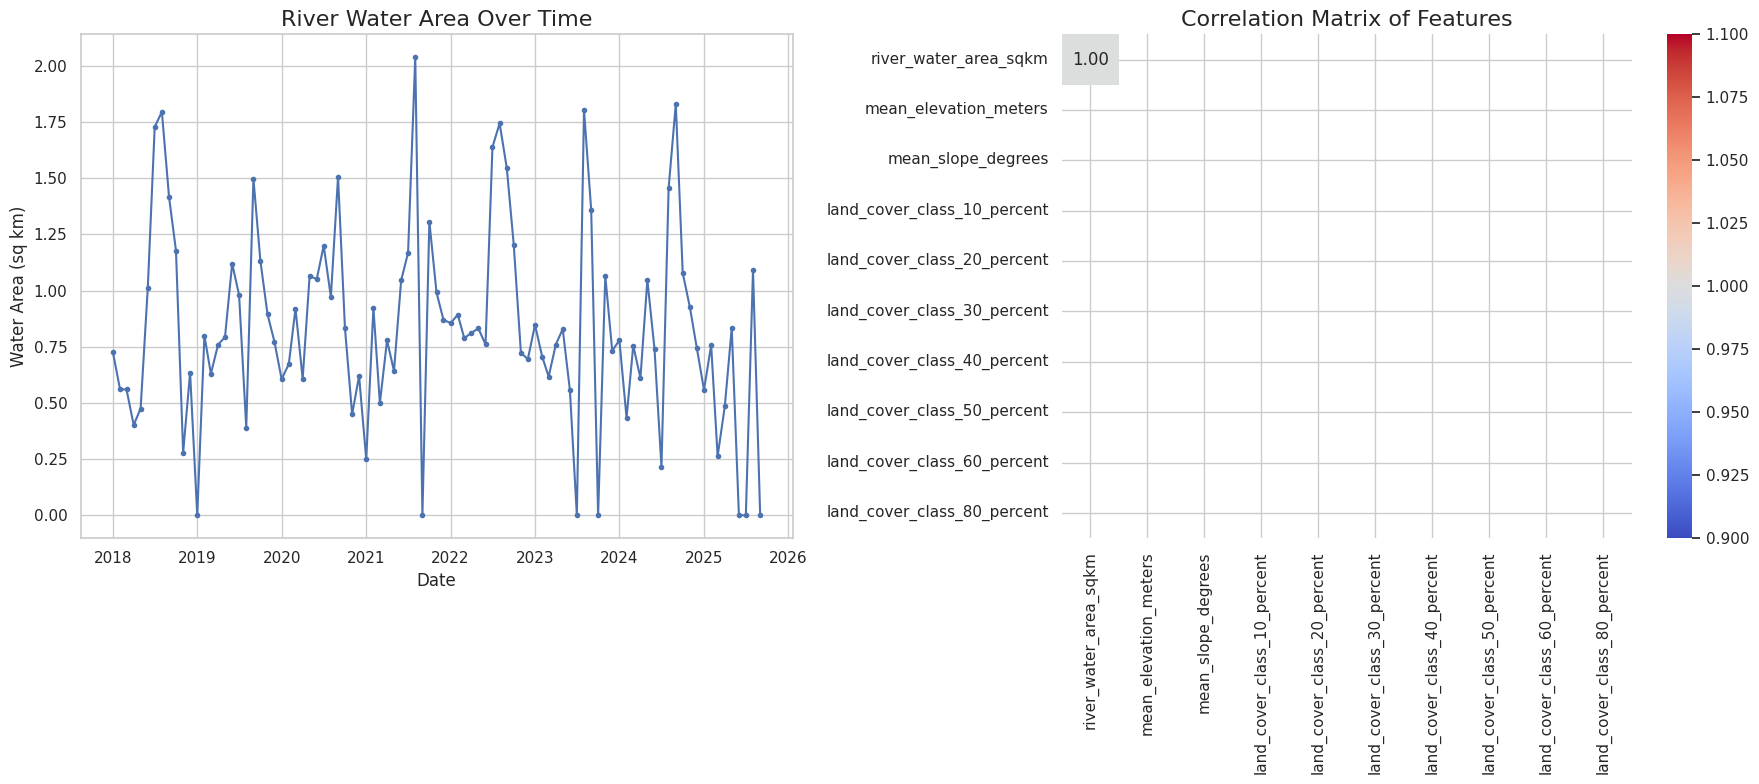

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- 0. Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
try:
    # Attempt to load the dataset from the uploaded CSV file
    df = pd.read_csv('final_river_data.csv')
    print("--- Successfully loaded 'final_rain_data.csv' ---")
except FileNotFoundError:
    # This is a fallback in case the file can't be accessed directly
    print("--- 'final_rain_data.csv' not found. Loading from provided text. ---")


# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# --- 2. Exploratory Data Analysis (EDA) ---
print("\n--- Descriptive Statistics ---")
print(df.describe().T)

# --- 3. Data Visualization ---
plt.figure(figsize=(18, 8))

# --- Visualization 1: Time Series of River Water Area ---
plt.subplot(1, 2, 1)
# **** FIX: Use df.index for plotting instead of df['date'] ****
plt.plot(df.index, df['river_water_area_sqkm'], marker='.', linestyle='-', color='b')
plt.title('River Water Area Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Water Area (sq km)', fontsize=12)
plt.grid(True)

# --- Visualization 2: Correlation Heatmap ---
plt.subplot(1, 2, 2)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features', fontsize=16)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

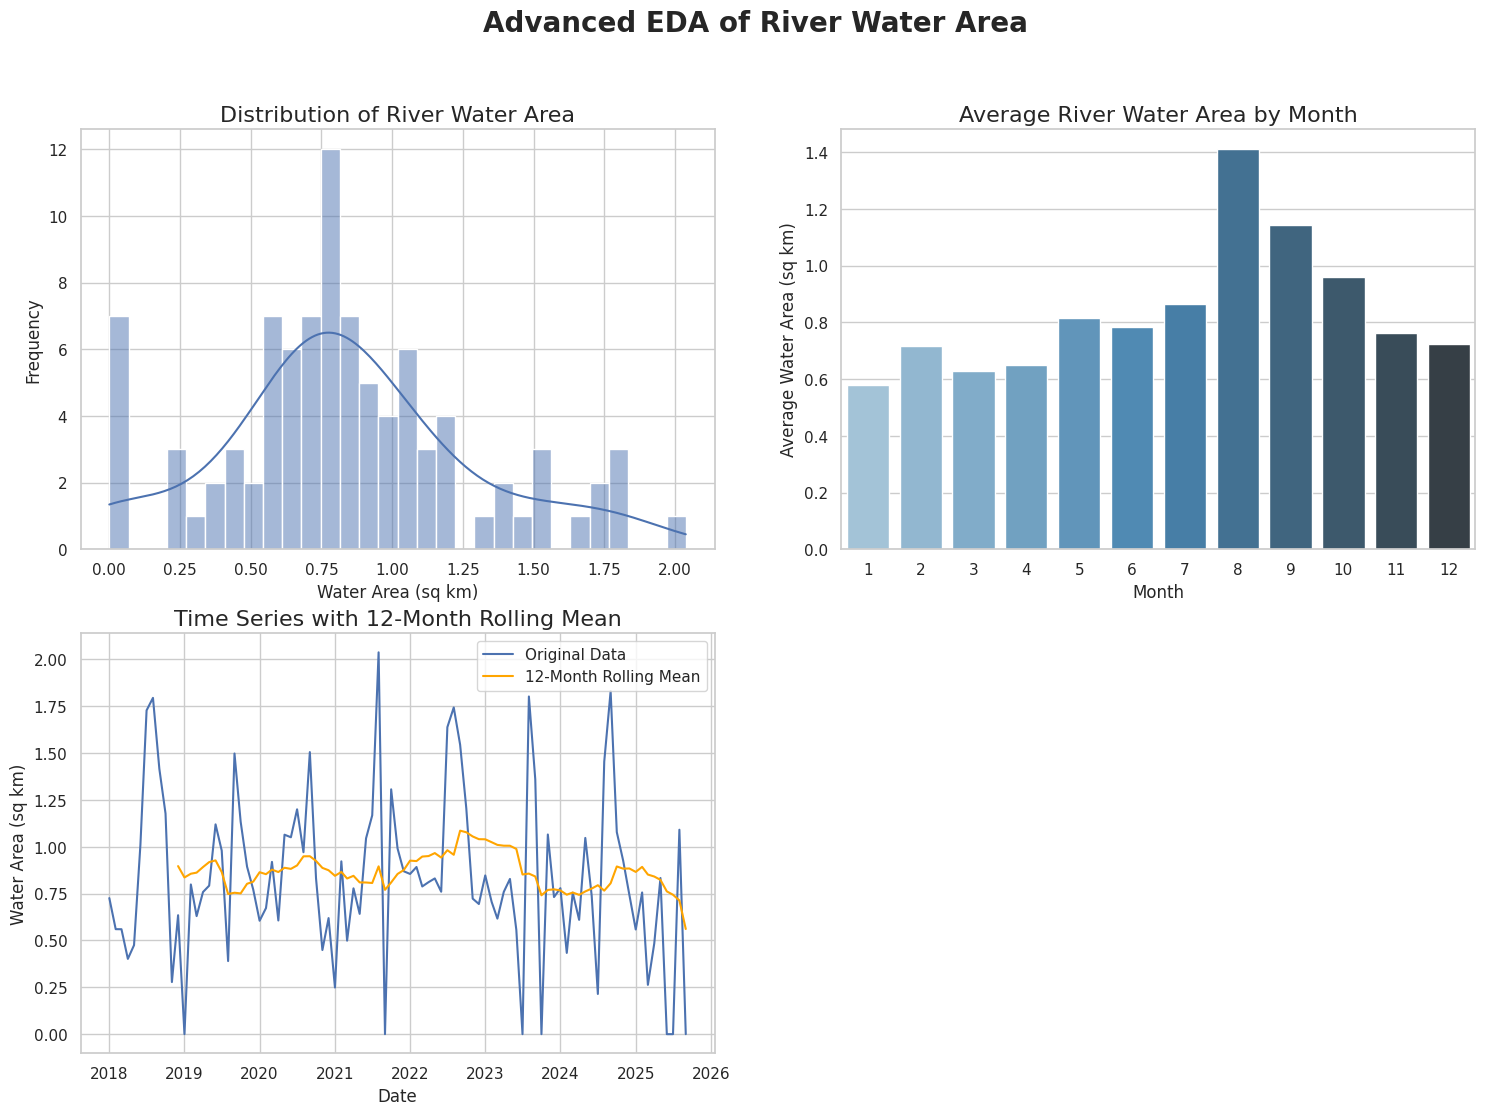

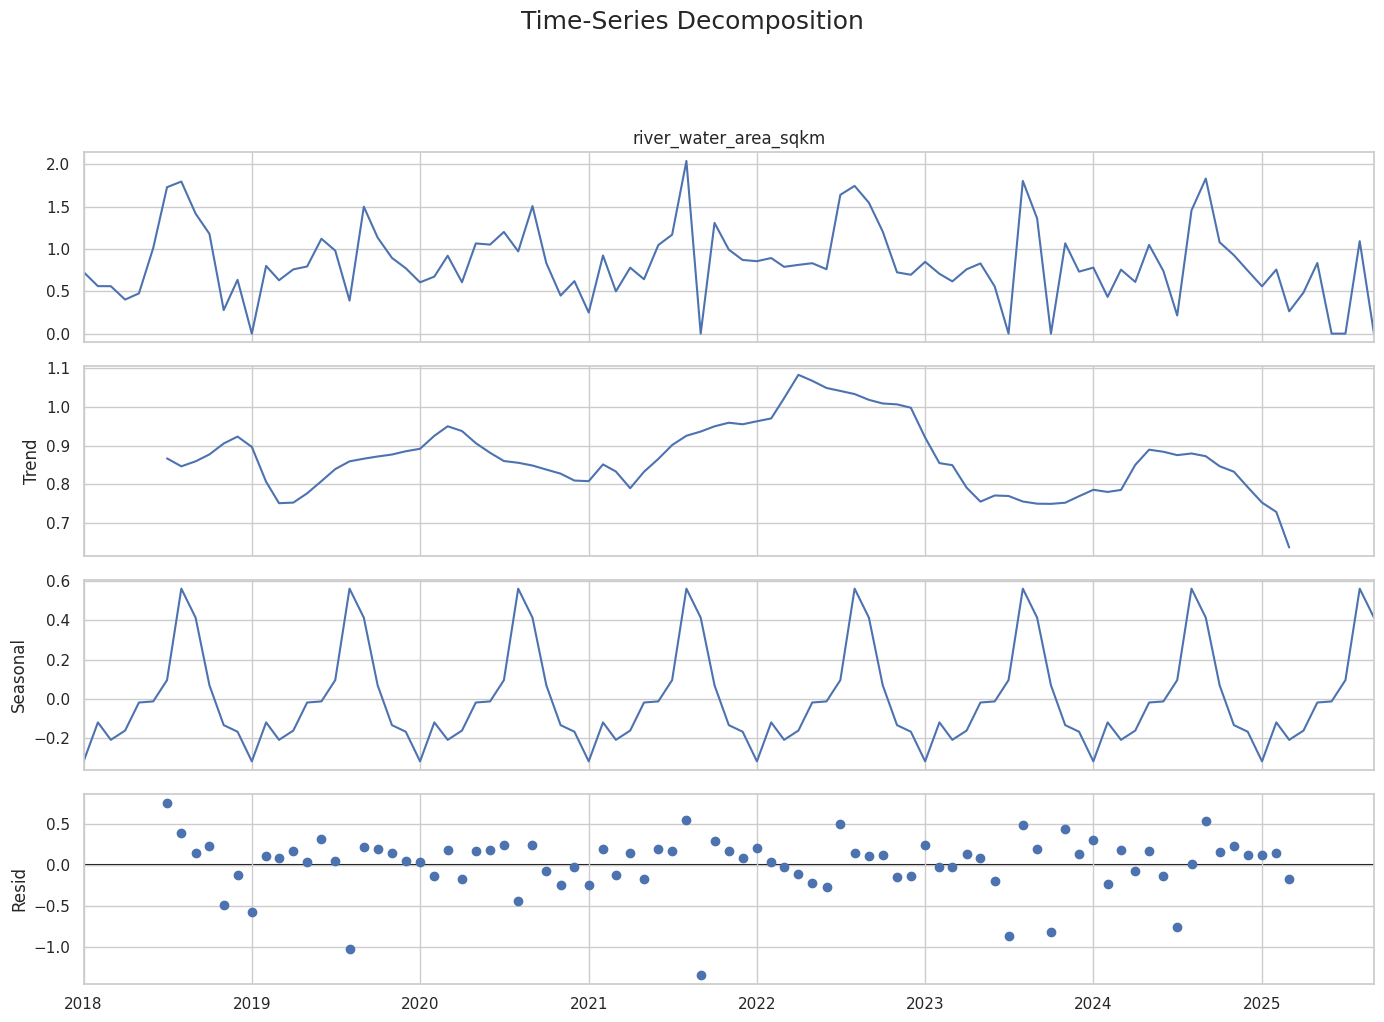

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 0. Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- 1. Load Data From Your Local File ---
# This assumes 'final_rain_data.csv' is in the same folder as your script.
df = pd.read_csv('final_river_data.csv')

# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# --- 2. Distribution Analysis ---
plt.figure(figsize=(18, 12))
plt.suptitle('Advanced EDA of River Water Area', fontsize=20, weight='bold')

# Plot 1: Histogram to show data distribution
plt.subplot(2, 2, 1)
sns.histplot(df['river_water_area_sqkm'], kde=True, bins=30)
plt.title('Distribution of River Water Area', fontsize=16)
plt.xlabel('Water Area (sq km)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# --- 3. Seasonal Pattern Analysis ---
# Plot 2: Bar chart for average area by month
plt.subplot(2, 2, 2)
# Create a 'month' column for grouping
df['month'] = df.index.month
monthly_avg = df.groupby('month')['river_water_area_sqkm'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='Blues_d')
plt.title('Average River Water Area by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Water Area (sq km)', fontsize=12)

# --- 4. Rolling Statistics Analysis ---
# Plot 3: Plotting the rolling mean
plt.subplot(2, 2, 3)
# Calculate a 12-month rolling mean
rolling_mean = df['river_water_area_sqkm'].rolling(window=12).mean()
plt.plot(df.index, df['river_water_area_sqkm'], label='Original Data')
plt.plot(df.index, rolling_mean, color='orange', label='12-Month Rolling Mean')
plt.title('Time Series with 12-Month Rolling Mean', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Water Area (sq km)', fontsize=12)
plt.legend()

# --- 5. Time-Series Decomposition ---
# Plot 4: Decomposing the time series
# The decomposition requires a certain number of periods, we'll assume a yearly seasonality (period=12)
# We will drop rows with missing values that can result from the rolling mean calculation for this plot
df_temp = df.dropna()
decomposition = seasonal_decompose(df_temp['river_water_area_sqkm'], model='additive', period=12)

# Create a separate figure for the decomposition plot as it contains multiple subplots
fig_decomposition = decomposition.plot()
fig_decomposition.set_size_inches(14, 10)
plt.suptitle('Time-Series Decomposition', y=1.02, fontsize=18)

# Show all plots
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

--- Successfully loaded 'final_river_data.csv' ---
--- Descriptive Statistics ---
                             count        mean           std         min  \
river_water_area_sqkm         93.0    0.837687  4.481990e-01    0.000000   
mean_elevation_meters         93.0  291.700789  1.143030e-13  291.700789   
mean_slope_degrees            93.0    5.154286  8.036932e-15    5.154286   
land_cover_class_10_percent   93.0   26.111203  2.500379e-14   26.111203   
land_cover_class_20_percent   93.0    1.665582  1.339489e-15    1.665582   
land_cover_class_30_percent   93.0   10.373379  1.250189e-14   10.373379   
land_cover_class_40_percent   93.0   20.170035  1.071591e-14   20.170035   
land_cover_class_50_percent   93.0   16.832981  2.857576e-14   16.832981   
land_cover_class_60_percent   93.0   11.531081  8.929924e-15   11.531081   
land_cover_class_80_percent   93.0   13.315739  1.071591e-14   13.315739   

                                    25%         50%         75%         max  
riv

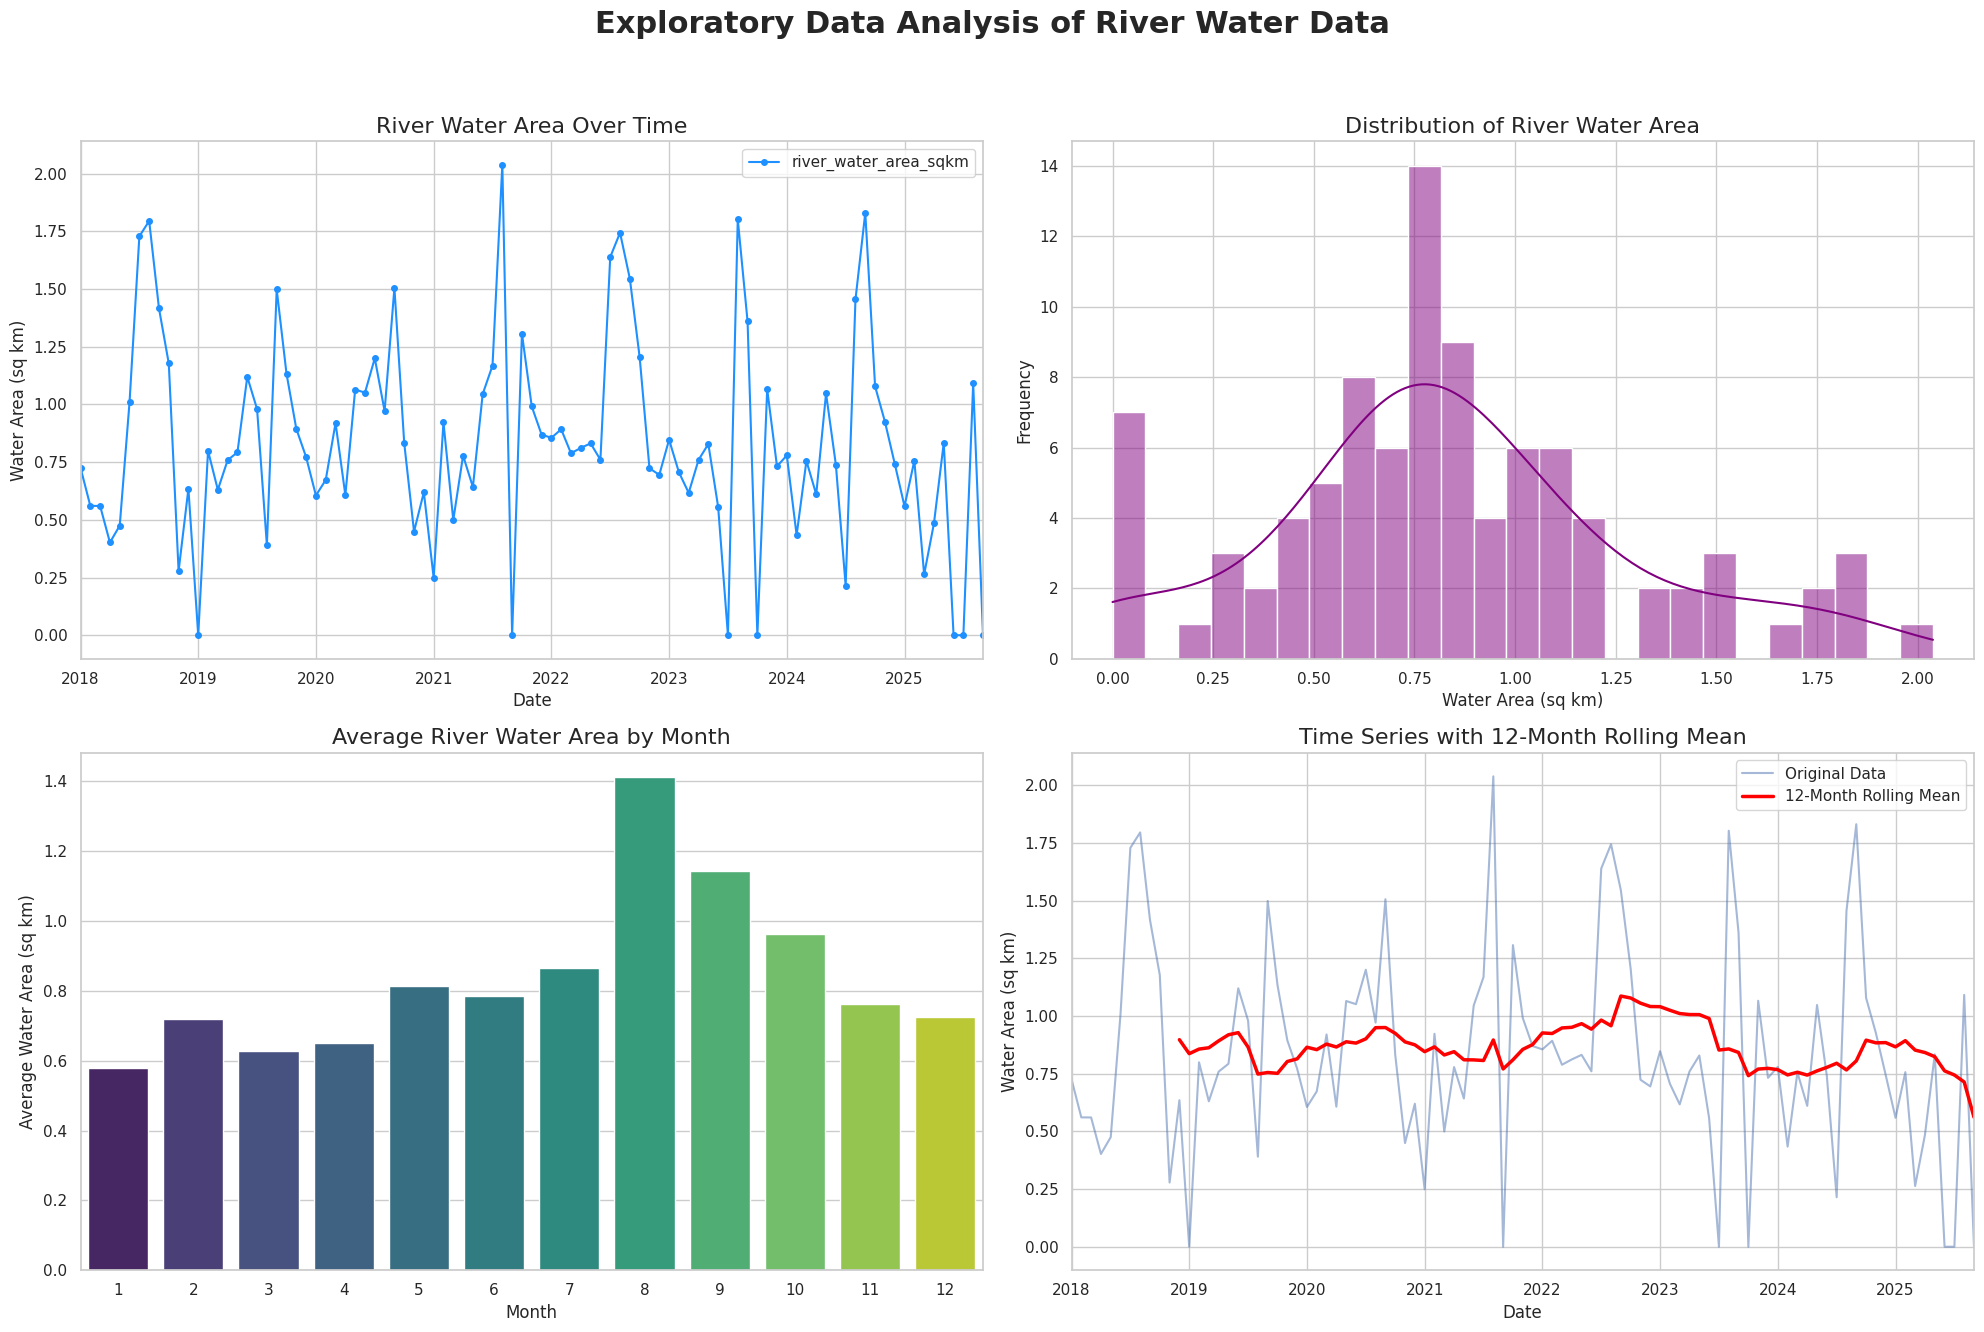

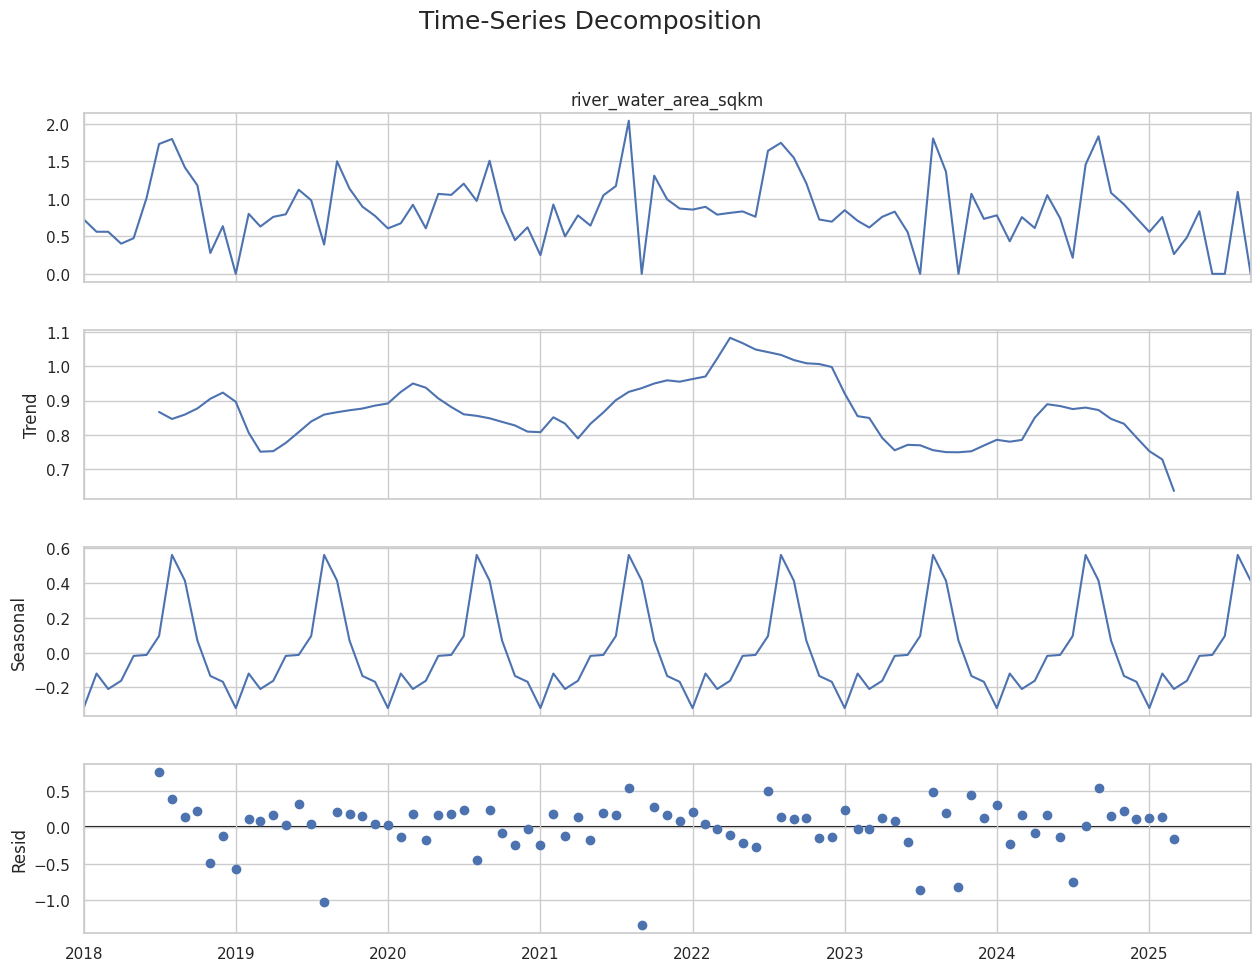

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 0. Setup ---
# This will ignore minor warnings for a cleaner output.
warnings.filterwarnings('ignore')
# This sets a consistent, professional style for all plots.
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
# This code assumes your CSV file is in the same folder as your script.
try:
    # Corrected file name to load the data with the 'date' column
    df = pd.read_csv('final_river_data.csv')
    print("--- Successfully loaded 'final_river_data.csv' ---")
except FileNotFoundError:
    print("Error: 'final_river_data.csv' not found.")
    print("Please make sure the CSV file is in the same directory.")
    # Exit the script if the data cannot be loaded.
    exit()

# --- 2. Data Preparation ---
# Convert the 'date' column to a proper datetime format.
df['date'] = pd.to_datetime(df['date'])
# Set the 'date' column as the index. This is the key step for time-series analysis.
df.set_index('date', inplace=True)

# --- 3. Exploratory Data Analysis (EDA) ---
print("--- Descriptive Statistics ---")
# Display summary statistics for all numerical columns.
print(df.describe().T)
print("\n" + "="*50 + "\n")

# --- 4. Data Visualization ---
# Create a large figure to hold the main plots.
plt.figure(figsize=(20, 14))
plt.suptitle('Exploratory Data Analysis of River Water Data', fontsize=22, weight='bold')

# Plot 1: Time Series of River Water Area
plt.subplot(2, 2, 1) # (2 rows, 2 columns, 1st plot)
# CORRECT: Plot the column directly. Pandas uses the index for the x-axis automatically.
df['river_water_area_sqkm'].plot(marker='o', linestyle='-', markersize=4, color='dodgerblue', legend=True)
plt.title('River Water Area Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Water Area (sq km)', fontsize=12)

# Plot 2: Histogram of River Water Area
plt.subplot(2, 2, 2)
sns.histplot(df['river_water_area_sqkm'], kde=True, bins=25, color='purple')
plt.title('Distribution of River Water Area', fontsize=16)
plt.xlabel('Water Area (sq km)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot 3: Average Water Area by Month
plt.subplot(2, 2, 3)
# CORRECT: Group by the month from the DataFrame's index.
monthly_avg = df.groupby(df.index.month)['river_water_area_sqkm'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis')
plt.title('Average River Water Area by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Water Area (sq km)', fontsize=12)

# Plot 4: Rolling Mean to Visualize Trend
plt.subplot(2, 2, 4)
# Calculate a 12-month rolling mean.
rolling_mean = df['river_water_area_sqkm'].rolling(window=12).mean()
# CORRECT: Plot both the original data and the rolling average.
df['river_water_area_sqkm'].plot(label='Original Data', alpha=0.5)
rolling_mean.plot(color='red', label='12-Month Rolling Mean', linewidth=2.5)
plt.title('Time Series with 12-Month Rolling Mean', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Water Area (sq km)', fontsize=12)
plt.legend()

# Adjust layout and display the first figure.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 5. Time-Series Decomposition ---
# This analysis requires at least two full seasonal cycles (24 months).
if len(df) >= 24:
    # Use a seasonal period of 12 for monthly data.
    decomposition = seasonal_decompose(df['river_water_area_sqkm'], model='additive', period=12)
    # The decomposition plot is complex, so it gets its own figure.
    fig_decomposition = decomposition.plot()
    fig_decomposition.set_size_inches(14, 10)
    plt.suptitle('Time-Series Decomposition', y=1.02, fontsize=18)
    plt.show()
else:
    print("Dataset is too short for a 12-month seasonal decomposition.")

--- Successfully loaded 'rainfall_data_combined.csv' ---

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34853 entries, 0 to 34852
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         34853 non-null  object 
 1   District      34853 non-null  object 
 2   Date          34853 non-null  object 
 3   Year          34853 non-null  int64  
 4   Month         34853 non-null  int64  
 5   Avg_rainfall  34853 non-null  float64
 6   Agency_name   34853 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.9+ MB

--- Missing Values Before Handling ---
State           0
District        0
Date            0
Year            0
Month           0
Avg_rainfall    0
Agency_name     0
dtype: int64

--- No missing values found in 'Avg_rainfall'. ---

--- Generating Visualizations... ---


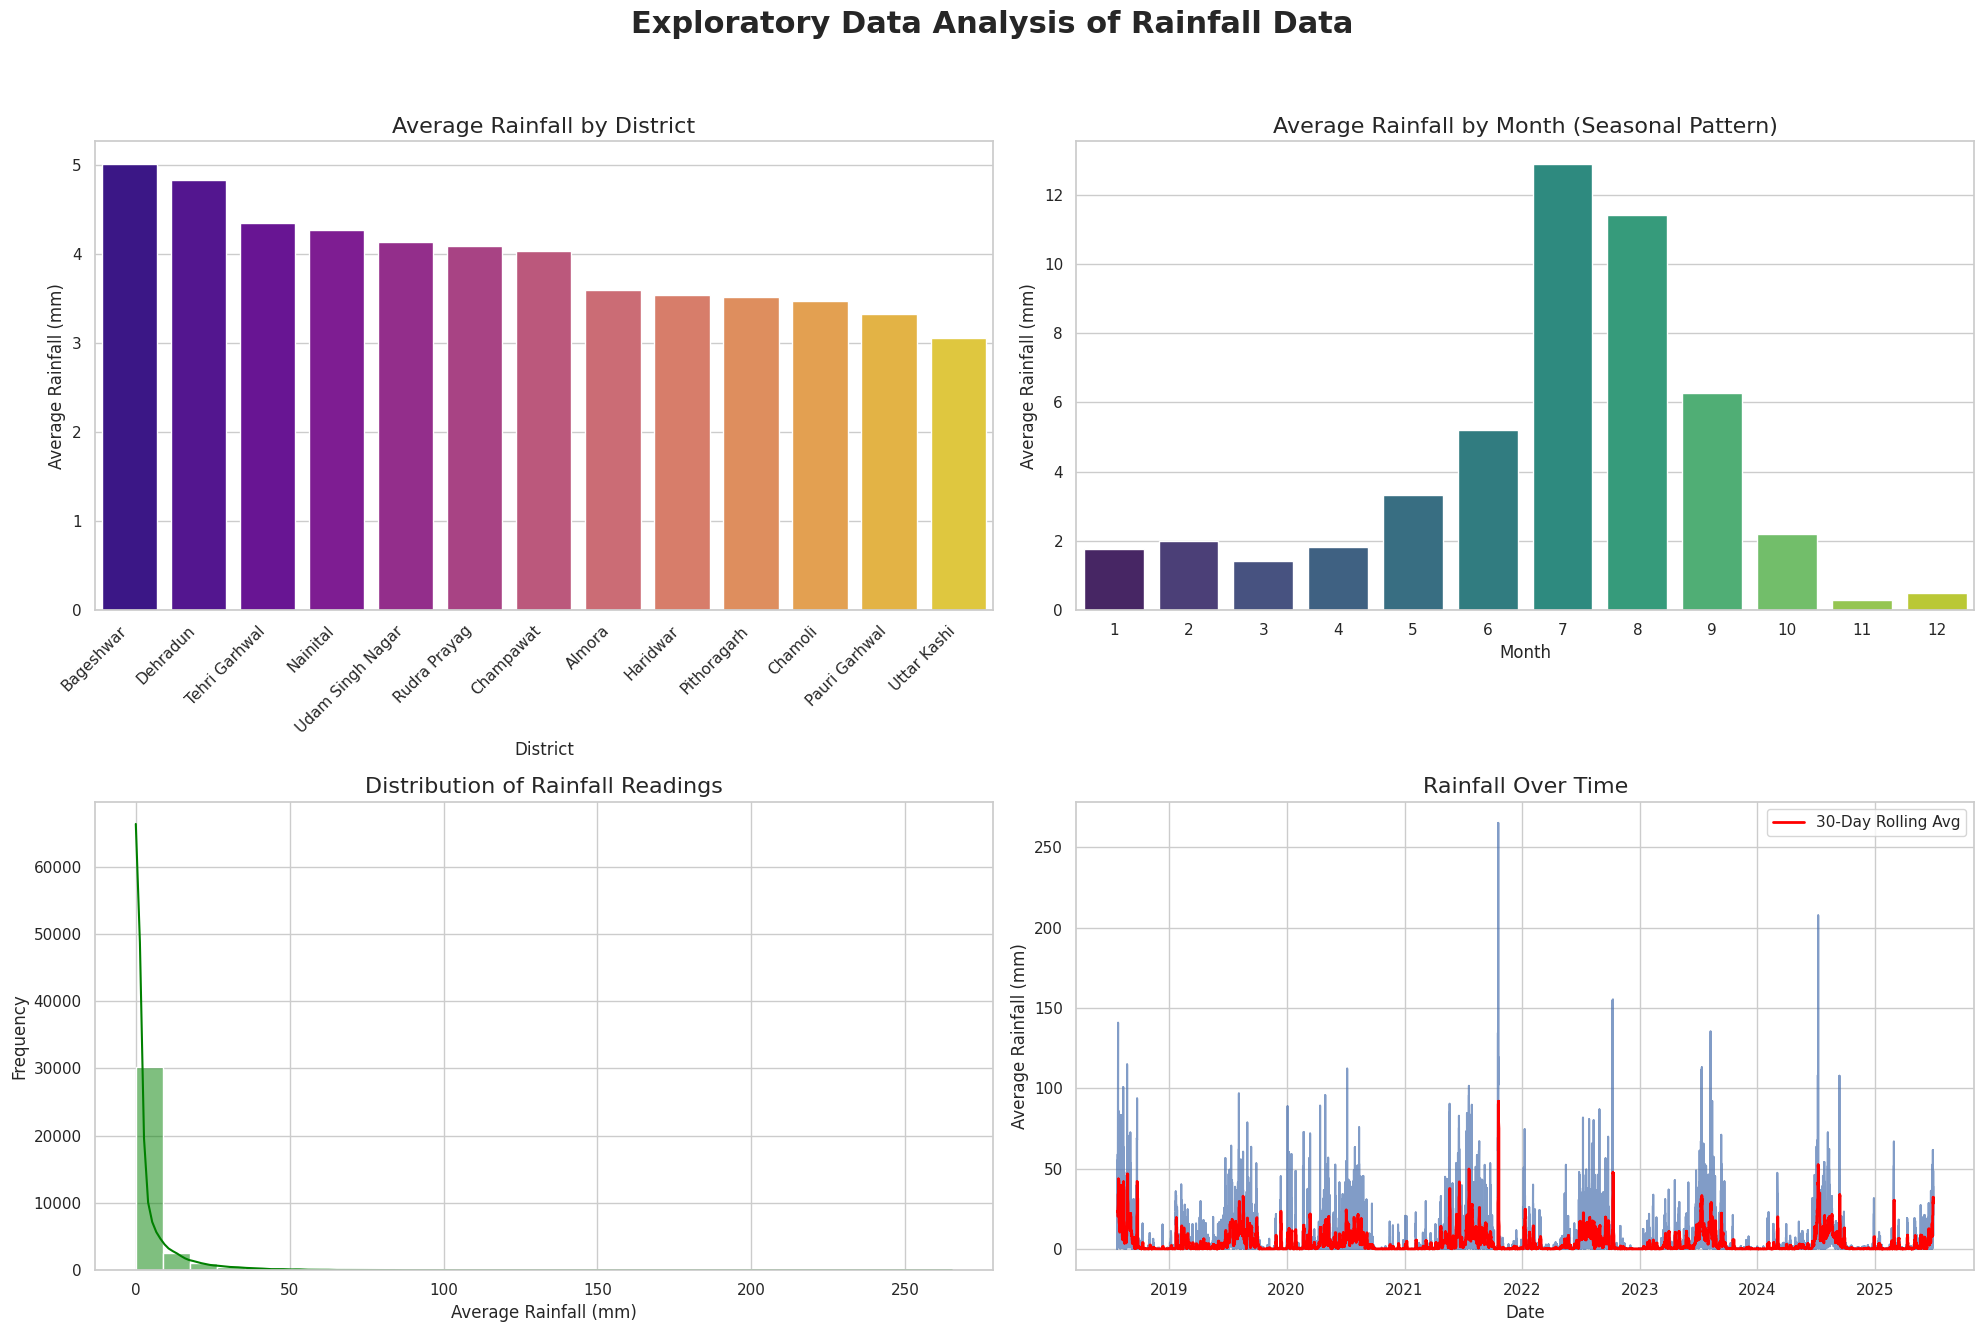

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- 0. Setup ---
# This will ignore minor warnings for a cleaner output.
warnings.filterwarnings('ignore')
# This sets a consistent, professional style for all plots.
sns.set_theme(style="whitegrid")

# --- 1. Data Loading and Initial Inspection ---
try:
    # This line reads the CSV file from your local folder.
    df = pd.read_csv('rainfall_data_combined.csv')
    print("--- Successfully loaded 'rainfall_data_combined.csv' ---")
except FileNotFoundError:
    print("Error: 'rainfall_data_combined.csv' not found.")
    print("Please make sure the CSV file is in the same directory as your script.")
    # Exit the script if the data cannot be loaded.
    exit()

# Display basic information about the dataset (data types, non-null counts)
print("\n--- Dataset Info ---")
df.info()

# --- 2. Handling Missing Values ---
print("\n--- Missing Values Before Handling ---")
missing_values = df.isnull().sum()
print(missing_values)

# Check if there are any missing values in 'Avg_rainfall'
if missing_values['Avg_rainfall'] > 0:
    # Impute missing 'Avg_rainfall' values with the mean of the column.
    # This is a common strategy to fill gaps without dropping valuable data.
    mean_rainfall = df['Avg_rainfall'].mean()
    df['Avg_rainfall'].fillna(mean_rainfall, inplace=True)
    print(f"\n--- Missing 'Avg_rainfall' values imputed with mean: {mean_rainfall:.2f} ---")
else:
    print("\n--- No missing values found in 'Avg_rainfall'. ---")

# --- 3. Data Preparation ---
# Convert the 'Date' column to a proper datetime format for time-series analysis.
df['Date'] = pd.to_datetime(df['Date'])

# --- 4. Exploratory Analysis and Visualization ---
print("\n--- Generating Visualizations... ---")

# Create a large figure to hold all the plots.
plt.figure(figsize=(20, 14))
plt.suptitle('Exploratory Data Analysis of Rainfall Data', fontsize=22, weight='bold')

# Plot 1: Average Rainfall by District
plt.subplot(2, 2, 1) # (2 rows, 2 columns, 1st plot)
avg_rainfall_district = df.groupby('District')['Avg_rainfall'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rainfall_district.index, y=avg_rainfall_district.values, palette='plasma')
plt.title('Average Rainfall by District', fontsize=16)
plt.xlabel('District', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Plot 2: Average Rainfall by Month
plt.subplot(2, 2, 2)
avg_rainfall_month = df.groupby('Month')['Avg_rainfall'].mean()
sns.barplot(x=avg_rainfall_month.index, y=avg_rainfall_month.values, palette='viridis')
plt.title('Average Rainfall by Month (Seasonal Pattern)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)

# Plot 3: Distribution of Average Rainfall
plt.subplot(2, 2, 3)
sns.histplot(df['Avg_rainfall'], kde=True, bins=30, color='green')
plt.title('Distribution of Rainfall Readings', fontsize=16)
plt.xlabel('Average Rainfall (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot 4: Rainfall Over Time (Time Series)
plt.subplot(2, 2, 4)
# Sort by date to ensure the line plot connects points chronologically.
df.sort_values('Date', inplace=True)
plt.plot(df['Date'], df['Avg_rainfall'], alpha=0.7)
# Plot a 30-day rolling average to see the trend more clearly.
plt.plot(df['Date'], df['Avg_rainfall'].rolling(window=30).mean(), color='red', linewidth=2, label='30-Day Rolling Avg')
plt.title('Rainfall Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.legend()

# Adjust layout to prevent plots from overlapping and display the figure.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()